# CIFAR-10 + MLP — MLX 우위 보이기

두 가지 변화로 MLX 가 NumPy 를 이기는 영역에 들어선다:

1. **연산량 ↑** — CIFAR-10 은 32×32×3 = **3072 차원** (MNIST 의 4배). MLP 도 3072 → 2048 → 1024 → 512 → 10 으로 키우고 batch=256.
2. **per-batch sync 제거** — Fashion-MNIST 노트북에선 매 배치 `to_numpy(pred)` 로 GPU↔CPU 왕복했지만 여기선 **on-device 누적** (correct/loss 를 tensor 스칼라로 유지하다 epoch 끝에 한 번만 변환). MLX lazy graph 가 길게 흐를 수 있어 GPU 가 진짜 일함.

추가로 — MLP 의 천장 (~50% test acc) 도 직접 확인. 이게 CNN 가야 하는 이유.

In [1]:
import time
from abc import ABC, abstractmethod
from collections.abc import Iterator

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from tqdm.notebook import tqdm

import axon
from axon import DType, xp
from axon.backend import Array, BackendName

## Optimizer

In [2]:
class Optimizer(ABC):
  def __init__(self, *, lr: float = 0.01):
    self._lr = lr

  @property
  def lr(self) -> float:
    return self._lr

  @abstractmethod
  def step(self, X: Array, dX: Array): ...


class Adam(Optimizer):
  def __init__(self, *, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    super().__init__(lr=lr)
    self.beta1 = beta1
    self.beta2 = beta2
    self.eps = eps
    self.t = 0
    self.m: dict[int, Array] = {}
    self.v: dict[int, Array] = {}

  def step(self, X: Array, dX: Array):
    pid = id(X)
    if pid not in self.m:
      self.m[pid] = xp.zeros_like(X)
      self.v[pid] = xp.zeros_like(X)
    self.t += 1
    self.m[pid] = self.beta1 * self.m[pid] + (1 - self.beta1) * dX
    self.v[pid] = self.beta2 * self.v[pid] + (1 - self.beta2) * dX**2
    m_hat = self.m[pid] / (1 - self.beta1**self.t)
    v_hat = self.v[pid] / (1 - self.beta2**self.t)
    X -= self.lr * m_hat / (xp.sqrt(v_hat) + self.eps)

## Module / Layer

In [3]:
class Module(ABC):
  @abstractmethod
  def forward(self, X: Array) -> Array: ...
  @abstractmethod
  def backward(self, delta: Array) -> Array: ...
  @abstractmethod
  def optimize(self, optimizer: Optimizer): ...
  @abstractmethod
  def format(self, indent: int = 0) -> str: ...

  def __repr__(self):
    return self.format()


class Linear(Module):
  W: Array[DType.FLOAT32]
  b: Array[DType.FLOAT32]
  dW: Array[DType.FLOAT32] | None
  db: Array[DType.FLOAT32] | None

  def __init__(self, in_features: int, out_features: int):
    self.in_features = in_features
    self.out_features = out_features
    self._cache_X: Array | None = None
    # Kaiming-He init for ReLU
    std = float(np.sqrt(2.0 / in_features))
    self.W = xp.random.normal((out_features, in_features), std=std, dtype=DType.FLOAT32)
    self.b = xp.zeros((out_features,), dtype=DType.FLOAT32)
    self.dW = None
    self.db = None

  def forward(self, X: Array) -> Array:
    self._cache_X = X
    return X @ xp.transpose(self.W) + self.b

  def backward(self, delta: Array) -> Array:
    X = self._cache_X
    assert X is not None
    self.db = xp.sum(delta, axis=0)
    self.dW = xp.transpose(delta) @ X
    return delta @ self.W

  def optimize(self, optimizer: Optimizer):
    assert self.dW is not None and self.db is not None
    optimizer.step(self.W, self.dW)
    optimizer.step(self.b, self.db)

  def format(self, indent: int = 0) -> str:
    return f"{'  ' * indent}Linear(in={self.in_features}, out={self.out_features})"


class ReLU(Module):
  def __init__(self):
    self._cache_X: Array | None = None

  def forward(self, X: Array) -> Array:
    self._cache_X = X
    return xp.maximum(xp.zeros_like(X), X)

  def backward(self, delta: Array) -> Array:
    X = self._cache_X
    assert X is not None
    return delta * (X > 0)

  def optimize(self, optimizer: Optimizer):
    pass

  def format(self, indent: int = 0) -> str:
    return f"{'  ' * indent}ReLU()"


class Sequential(Module):
  def __init__(self, modules: list[Module]):
    self.modules = modules

  def forward(self, X: Array) -> Array:
    x = X
    for m in self.modules:
      x = m.forward(x)
    return x

  def backward(self, delta: Array) -> Array:
    d = delta
    for m in reversed(self.modules):
      d = m.backward(d)
    return d

  def optimize(self, optimizer: Optimizer):
    for m in self.modules:
      m.optimize(optimizer)

  def format(self, indent: int = 0) -> str:
    indent_str = "  " * indent
    lines = [f"{indent_str}Sequential("]
    for m in self.modules:
      lines.append(f"{m.format(indent + 1)},")
    lines.append(f"{indent_str})")
    return "\n".join(lines)

## Loss — tensor 반환 (on-device 누적용)

이전 노트북들과 다르게 `forward` 가 Python `float` 가 아니라 **tensor 스칼라** 를 반환. `float(...)` 변환은 epoch 끝에 한 번만 — MLX lazy graph 가 길게 흐를 수 있게.

In [4]:
class CrossEntropyLoss:
  def __init__(self):
    self._cache_probs: Array | None = None
    self._cache_T: Array | None = None
    self._cache_N: int | None = None

  def forward(self, Y: Array, T: Array) -> Array:
    """loss 를 0-d Array 로 반환 (Python float 아님)."""
    N = int(Y.shape[0])
    max_by_row = xp.max(Y, axis=1, keepdims=True)
    shifted = Y - max_by_row
    exp_shifted = xp.exp(shifted)
    sum_by_row = xp.sum(exp_shifted, axis=1, keepdims=True)
    probs = exp_shifted / sum_by_row

    n = xp.arange(N, dtype=DType.INT32)
    log_probs = xp.log(probs[n, T] + 1e-9)

    self._cache_probs = probs
    self._cache_T = T
    self._cache_N = N

    return -xp.mean(log_probs)

  def backward(self) -> Array:
    probs = self._cache_probs
    T = self._cache_T
    N = self._cache_N
    assert probs is not None and T is not None and N is not None

    dY = xp.array(probs)
    n = xp.arange(N, dtype=DType.INT32)
    dY[n, T] -= 1.0
    dY /= N
    return dY

## CIFAR-10 로드

OpenML 에서 받음 — 첫 fetch 는 **170MB 다운로드** 라 1~2분 걸림 (이후 로컬 캐시).
Train 50k / test 10k, 32×32×3 RGB, 10 클래스.

In [5]:
import os
import pickle
import tarfile
import urllib.request

CIFAR_CLASSES = [
  "airplane", "automobile", "bird", "cat", "deer",
  "dog", "frog", "horse", "ship", "truck",
]


def _fetch_cifar_openml():
  """OpenML 경로. checksum 실패 시 캐시 정리 후 한 번 재시도."""
  try:
    bunch = fetch_openml("CIFAR_10", version=1, as_frame=False, parser="liac-arff")
  except ValueError as e:
    if "checksum" not in str(e):
      raise
    from sklearn.datasets import get_data_home
    cache = get_data_home()
    for root, _, fnames in os.walk(cache):
      for fn in fnames:
        if "CIFAR" in fn.upper() or "16797613" in fn:
          os.remove(os.path.join(root, fn))
    print("checksum 불일치 — OpenML 캐시 삭제 후 재시도 …")
    bunch = fetch_openml("CIFAR_10", version=1, as_frame=False, parser="liac-arff")
  return bunch.data, bunch.target


def _fetch_cifar_direct():
  """Toronto canonical source 에서 직접 다운로드 (~170MB tar.gz)."""
  url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
  cache_root = os.path.expanduser("~/scikit_learn_data/cifar10_direct")
  targz = os.path.join(cache_root, "cifar-10-python.tar.gz")
  extracted = os.path.join(cache_root, "cifar-10-batches-py")

  if not os.path.exists(extracted):
    os.makedirs(cache_root, exist_ok=True)
    if not os.path.exists(targz):
      print(f"downloading CIFAR-10 from {url} (~170MB) …")
      urllib.request.urlretrieve(url, targz)
    with tarfile.open(targz) as tf:
      tf.extractall(cache_root)

  def _load(fn):
    with open(os.path.join(extracted, fn), "rb") as f:
      return pickle.load(f, encoding="bytes")

  parts = [_load(f"data_batch_{i}") for i in range(1, 6)] + [_load("test_batch")]
  X = np.concatenate([p[b"data"] for p in parts])  # (60000, 3072) uint8, channel-major
  T = np.array([label for p in parts for label in p[b"labels"]], dtype=np.int64)
  return X, T


def _fetch_cifar():
  try:
    return _fetch_cifar_openml()
  except Exception as e:
    print(f"OpenML 실패 ({type(e).__name__}: {e}). Toronto 직접 다운로드로 fallback …")
    return _fetch_cifar_direct()


X_all_raw, T_all_raw = _fetch_cifar()
X_all = X_all_raw.astype(np.float32) / 255.0
T_all = T_all_raw.astype(np.int32)

# Train 50k / test 10k 로 자름. (Toronto 는 batch 1~5 = train 50k, test_batch = test 10k 순서이므로 그대로 유효)
X_train_np, X_test_np = X_all[:50000], X_all[50000:]
T_train_np, T_test_np = T_all[:50000], T_all[50000:]

print("train:", X_train_np.shape, "test:", X_test_np.shape)
print("feature dim:", X_train_np.shape[1], "(= 32×32×3)")


/Users/rhseung/Dev/rhseung/axon/.venv/lib/python3.14/site-packages/sklearn/datasets/_openml.py:74: RuntimeWarning: Invalid cache, redownloading file
  warn("Invalid cache, redownloading file", RuntimeWarning)


checksum 불일치 — OpenML 캐시 삭제 후 재시도 …
OpenML 실패 (ValueError: md5 checksum of local file for https://openml.org/data/v1/download/16797613/CIFAR_10.arff does not match description: expected: 556e01684912de400da7557c57155b97 but got 82b69adac6404e7436cdf945347ae810. Downloaded file could have been modified / corrupted, clean cache and retry...). Toronto 직접 다운로드로 fallback …
downloading CIFAR-10 from https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz (~170MB) …


/var/folders/sf/nvt_gtqx6c970wj9fj9sf9h00000gn/T/ipykernel_54324/96788273.py:47: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="bytes")


train: (50000, 3072) test: (10000, 3072)
feature dim: 3072 (= 32×32×3)


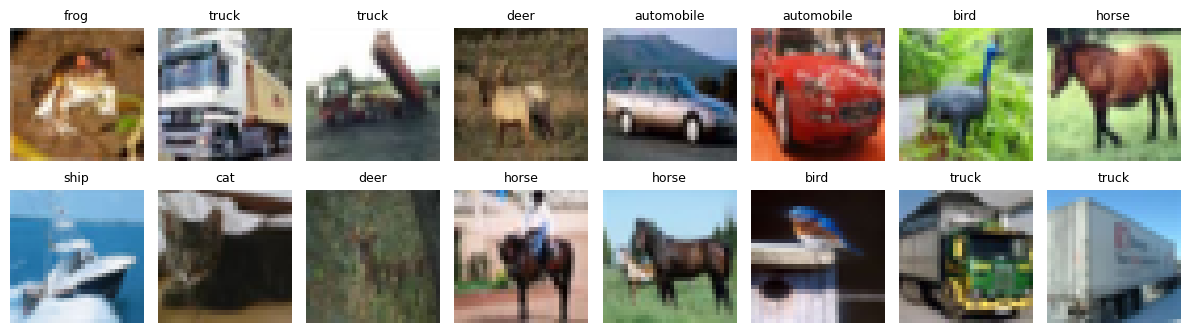

In [6]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i, ax in enumerate(axes.flat):
  img = X_train_np[i].reshape(3, 32, 32).transpose(1, 2, 0)
  ax.imshow(img)
  ax.set_title(CIFAR_CLASSES[T_train_np[i]], fontsize=9)
  ax.axis("off")
plt.tight_layout()
plt.show()

## 학습 루프 — on-device 누적

**핵심 차이** (이전 노트북들 대비):

```python
# 이전: 매 배치 to_numpy → MLX lazy graph 강제 eval, GPU↔CPU 왕복
pred_np = axon.current().to_numpy(pred)
t_np = axon.current().to_numpy(t)
total_correct += int((pred_np == t_np).sum())

# 지금: on-device 누적, epoch 끝에 한 번만 변환
total_correct += xp.sum(pred == t)
...
return float(total_correct) / N   # ← 한 번만 sync
```

In [7]:
def iterate_minibatches(
  X_np: np.ndarray, T_np: np.ndarray, batch_size: int, *, shuffle: bool = False
) -> Iterator[tuple[Array, Array]]:
  N = X_np.shape[0]
  indices = np.random.permutation(N) if shuffle else np.arange(N)
  for start in range(0, N, batch_size):
    batch_idx = indices[start : start + batch_size]
    yield xp.from_numpy(X_np[batch_idx]), xp.from_numpy(T_np[batch_idx])


def run_epoch(
  module: Module,
  loss_fn: CrossEntropyLoss,
  X_np: np.ndarray,
  T_np: np.ndarray,
  *,
  batch_size: int,
  training: bool,
  optimizer: Optimizer | None = None,
) -> dict[str, float]:
  N = X_np.shape[0]
  # on-device 누적
  total_loss = xp.zeros((), dtype=DType.FLOAT32)
  total_correct = xp.zeros((), dtype=DType.INT64)
  total_seen = 0

  total_steps = (N + batch_size - 1) // batch_size
  batches = iterate_minibatches(X_np, T_np, batch_size, shuffle=training)

  for x, t in tqdm(batches, total=total_steps, leave=False):
    n = x.shape[0]
    y = module.forward(x)
    loss = loss_fn.forward(y, t)  # tensor scalar

    if training:
      assert optimizer is not None
      dy = loss_fn.backward()
      module.backward(dy)
      module.optimize(optimizer)

    pred = xp.argmax(y, axis=1)
    correct_batch = xp.sum((pred == t))
    total_correct += correct_batch
    total_loss += loss * n
    total_seen += n

  # epoch 끝에 한 번만 변환
  return {
    "loss": float(total_loss) / total_seen,
    "accuracy": float(total_correct) / total_seen,
  }


def train(
  module: Module,
  optimizer: Optimizer,
  loss_fn: CrossEntropyLoss,
  X_train_np: np.ndarray,
  T_train_np: np.ndarray,
  X_test_np: np.ndarray,
  T_test_np: np.ndarray,
  *,
  epochs: int,
  batch_size: int,
  test_batch_size: int,
  log_prefix: str = "",
) -> dict[str, list[float]]:
  history: dict[str, list[float]] = {
    "train_loss": [], "train_acc": [],
    "test_loss": [], "test_acc": [],
  }
  for epoch in range(1, epochs + 1):
    train_metrics = run_epoch(
      module, loss_fn, X_train_np, T_train_np,
      batch_size=batch_size, training=True, optimizer=optimizer,
    )
    test_metrics = run_epoch(
      module, loss_fn, X_test_np, T_test_np,
      batch_size=test_batch_size, training=False,
    )
    history["train_loss"].append(train_metrics["loss"])
    history["train_acc"].append(train_metrics["accuracy"])
    history["test_loss"].append(test_metrics["loss"])
    history["test_acc"].append(test_metrics["accuracy"])
    print(
      f"{log_prefix}epoch {epoch}/{epochs} | "
      f"train_loss={train_metrics['loss']:.4f} | "
      f"train_acc={train_metrics['accuracy']:.4%} | "
      f"test_loss={test_metrics['loss']:.4f} | "
      f"test_acc={test_metrics['accuracy']:.4%}"
    )
  return history

## 두 백엔드 동시 학습 — 큰 모델 + 큰 배치

모델 파라미터 ~8.4M (= 3072×2048 + 2048×1024 + 1024×512 + 512×10).
Batch=256 으로 GPU 가 일할 만큼 줌.

In [8]:
EPOCHS = 10
BATCH_SIZE = 256
TEST_BATCH_SIZE = 512
SEED = 0


def build_model() -> Sequential:
  return Sequential(
    [
      Linear(3072, 2048),
      ReLU(),
      Linear(2048, 1024),
      ReLU(),
      Linear(1024, 512),
      ReLU(),
      Linear(512, 10),
    ]
  )


def count_params(model: Sequential) -> int:
  total = 0
  for m in model.modules:
    if isinstance(m, Linear):
      total += m.W.shape[0] * m.W.shape[1] + m.b.shape[0]
  return total


results: dict[BackendName, dict] = {}

for backend in ("numpy", "mlx"):
  axon.set_backend(backend)
  np.random.seed(SEED)
  xp.random.seed(SEED)

  model = build_model()
  optimizer = Adam(lr=5e-4)
  loss_fn = CrossEntropyLoss()

  print(f"\n=== backend={backend} (params: {count_params(model):,}) ===")
  print(model)
  t0 = time.time()
  history = train(
    model, optimizer, loss_fn,
    X_train_np, T_train_np, X_test_np, T_test_np,
    epochs=EPOCHS, batch_size=BATCH_SIZE, test_batch_size=TEST_BATCH_SIZE,
    log_prefix=f"[{backend}] ",
  )
  elapsed = time.time() - t0
  results[backend] = {"history": history, "elapsed": elapsed}
  print(f"[{backend}] total time: {elapsed:.2f}s")


=== backend=numpy (params: 8,921,610) ===
Sequential(
  Linear(in=3072, out=2048),
  ReLU(),
  Linear(in=2048, out=1024),
  ReLU(),
  Linear(in=1024, out=512),
  ReLU(),
  Linear(in=512, out=10),
)


  0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

[numpy] epoch 1/10 | train_loss=1.9544 | train_acc=30.8600% | test_loss=1.7166 | test_acc=38.3900%


  0%|          | 0/196 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

[mlx] epoch 9/10 | train_loss=1.2782 | train_acc=54.6380% | test_loss=1.3735 | test_acc=51.4400%


  0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

[mlx] epoch 10/10 | train_loss=1.2456 | train_acc=55.5840% | test_loss=1.3625 | test_acc=52.5000%
[mlx] total time: 33.98s


## 결과 비교

In [9]:
print(f"{'backend':<10} {'final train_acc':>16} {'final test_acc':>16} {'time':>10} {'speedup':>10}")
np_time = results.get("numpy", {}).get("elapsed", 0.0)
for backend, res in results.items():
  h = res["history"]
  speedup = np_time / res["elapsed"] if res["elapsed"] > 0 else 0.0
  print(
    f"{backend:<10} "
    f"{h['train_acc'][-1]:>15.4%} "
    f"{h['test_acc'][-1]:>15.4%} "
    f"{res['elapsed']:>9.2f}s "
    f"{speedup:>9.2f}x"
  )

backend     final train_acc   final test_acc       time    speedup
numpy             55.4680%        51.4800%     58.45s      1.00x
mlx               55.5840%        52.5000%     33.98s      1.72x


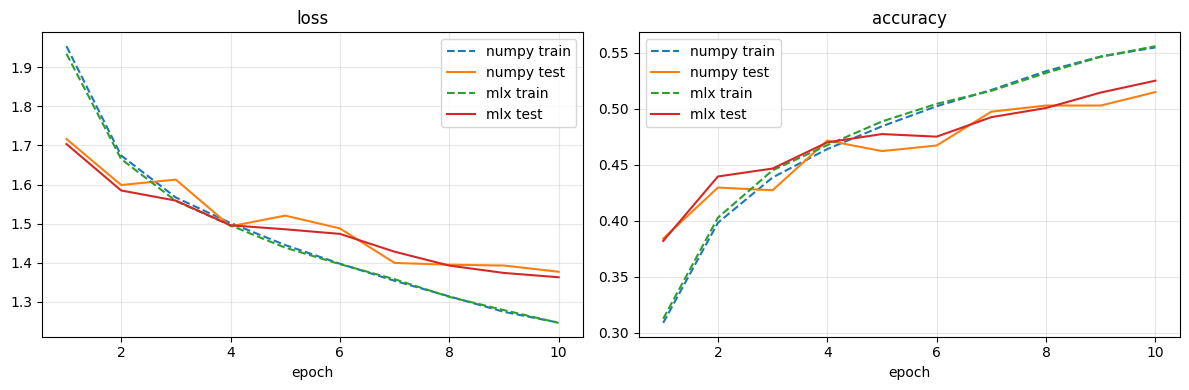

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, EPOCHS + 1)

for backend, res in results.items():
  h = res["history"]
  axes[0].plot(epochs_x, h["train_loss"], label=f"{backend} train", linestyle="--")
  axes[0].plot(epochs_x, h["test_loss"], label=f"{backend} test")
  axes[1].plot(epochs_x, h["train_acc"], label=f"{backend} train", linestyle="--")
  axes[1].plot(epochs_x, h["test_acc"], label=f"{backend} test")

axes[0].set_title("loss")
axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("accuracy")
axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 정리

**기대치**
- test acc ~50% 부근 천장 — MLP 의 한계. RGB 자연 이미지에서 픽셀 단위 dense 모델이 공간적 패턴을 잡지 못함
- MLX 가 NumPy 보다 빠름 (모델 / 배치가 충분히 크고, sync 가 적어졌으므로)

**여기서 더 짜내려면**
- CNN — 공간적 inductive bias
- Data augmentation (random crop, horizontal flip)
- Dropout / batch norm

→ 다음 마일스톤은 Tensor / autograd 마이그레이션, 그 위에 CNN.